<a href="https://colab.research.google.com/github/Ibravrca-18/PEMROSESANBAHASAALAMI/blob/main/TGS8_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
drive.mount('/content/drive')
csv_path = '/content/drive/My Drive/NLP/Lazada.csv'
df = pd.read_csv(csv_path, encoding='ISO-8859-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
print(df.columns)

Index(['itemId', 'category', 'name', 'brandName', 'url', 'price',
       'averageRating', 'totalReviews', 'retrievedDate'],
      dtype='object')


In [11]:
text_data = df['name'].astype(str)
text = " ".join(text_data)

text = text.lower()
text = re.sub(r'http\S+', '', text)
text = re.sub(r'[^a-zA-Z\s]', '', text)
text = re.sub(r'\s+', ' ', text)

In [12]:
stop_words = set(stopwords.words('indonesian'))
words = [word for word in text.split() if word not in stop_words]

In [13]:
bigrams = list(ngrams(words, 2))

In [14]:
bigram_counts = Counter(bigrams)

In [15]:
top_bigrams = bigram_counts.most_common(10)

for bg, freq in top_bigrams:
    print(bg, ":", freq)

('led', 'tv') : 1219
('ram', 'gb') : 1081
('flash', 'drive') : 929
('flash', 'disk') : 725
('gb', 'gb') : 711
('gb', 'usb') : 671
('gb', 'tb') : 611
('usb', 'flash') : 605
('tv', 'inch') : 526
('lenovo', 'ideapad') : 515


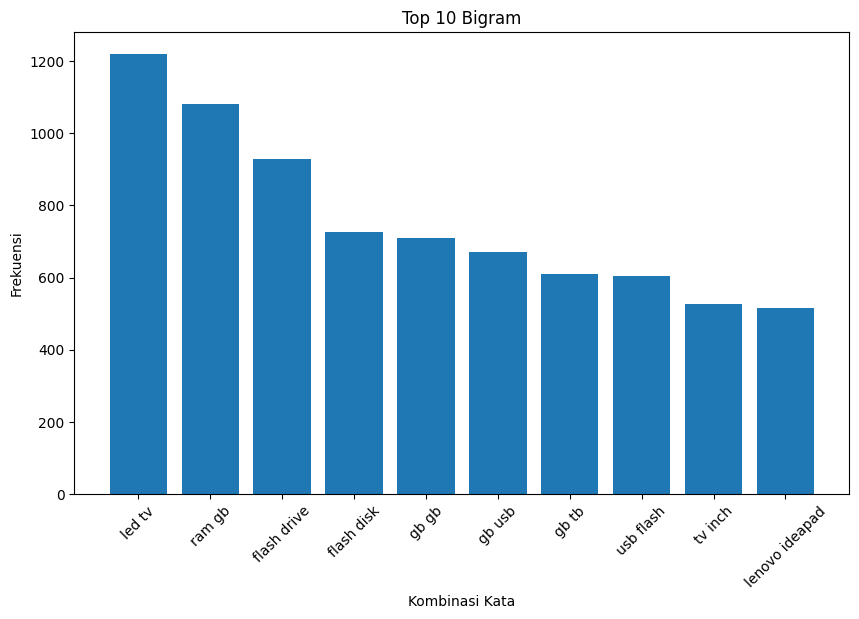

In [16]:
labels = [' '.join(bg) for bg, _ in top_bigrams]
values = [freq for _, freq in top_bigrams]

plt.figure(figsize=(10,6))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top 10 Bigram")
plt.xlabel("Kombinasi Kata")
plt.ylabel("Frekuensi")

plt.show()

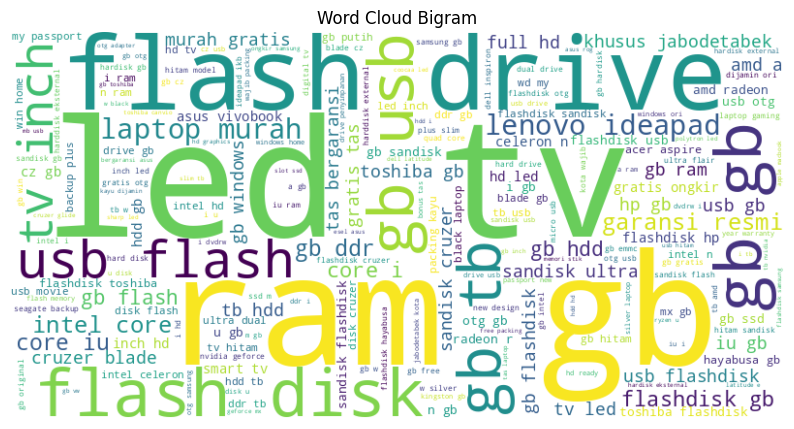

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ubah bigram jadi string (contoh: ('barang','bagus') → "barang bagus")
bigram_dict = {' '.join(k): v for k, v in bigram_counts.items()}

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white')\
.generate_from_frequencies(bigram_dict)

# Tampilkan
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Bigram')

plt.show()